## Prac 07.1

In this homework, you are going to use the code from ```TrafficSignsClassification``` notebook and create your own traffic sign classifier.

### Step 1
Use the data from ```data/subset_homework``` folder and visualize some examples. How many images are there for each class?



In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input
from sklearn.metrics import accuracy_score

plt.rcParams['figure.figsize'] = [15, 6]

First class (0): 2220 images
Second class (1): 2250 images


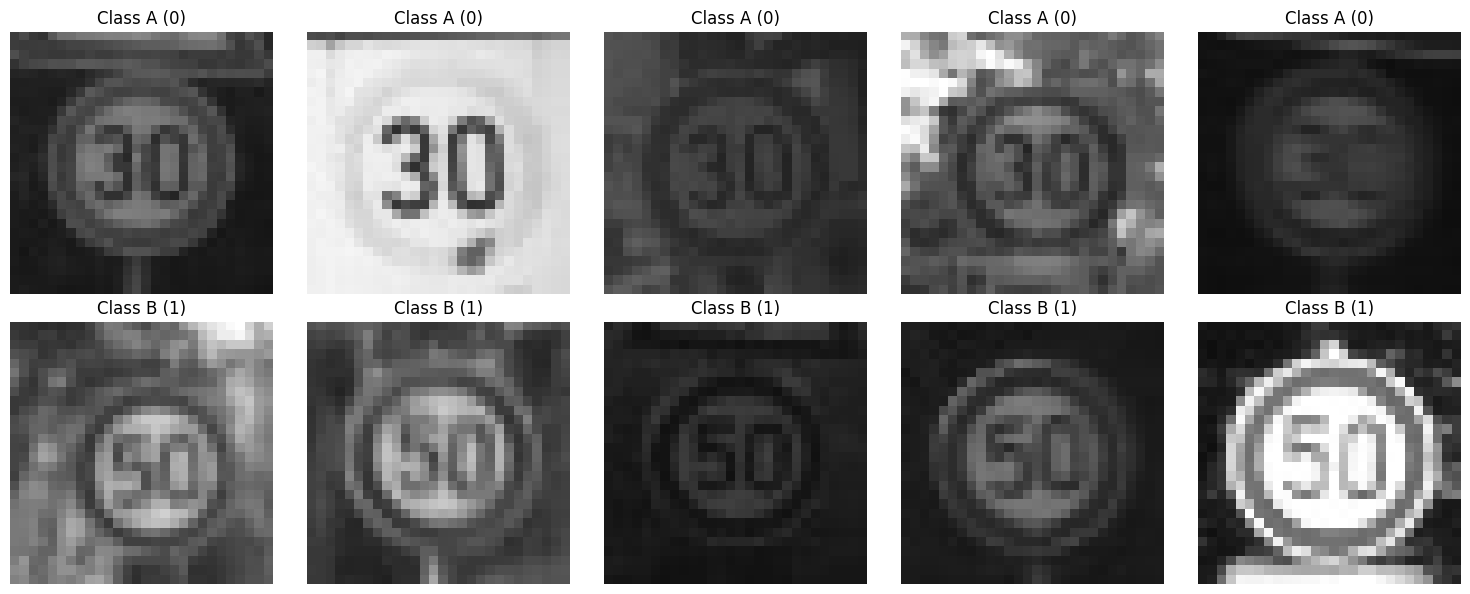

In [8]:
data_folder = '/content/drive/MyDrive/Prac 6/Prac_07/Prac 07.1/data/data/subset_homework'

filenames_a = os.listdir(os.path.join(data_folder, 'class_id_0'))
images_a = [cv2.imread(os.path.join(data_folder, 'class_id_0', file), cv2.IMREAD_UNCHANGED) for file in filenames_a]
labels_a = [0] * len(images_a)

filenames_b = os.listdir(os.path.join(data_folder, 'class_id_1'))
images_b = [cv2.imread(os.path.join(data_folder, 'class_id_1', file), cv2.IMREAD_UNCHANGED) for file in filenames_b]
labels_b = [1] * len(images_b)

images = images_a + images_b
labels = np.array(labels_a + labels_b)
images, labels = shuffle(images, labels, random_state=42)

images_array = np.array(images)
pixels = images_array.reshape(len(images_array), -1) / 255.0

print(f"First class (0): {len(images_a)} images")
print(f"Second class (1): {len(images_b)} images")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for col_index in range(5):
    random_idx_a = np.random.randint(0, len(images_a))
    axes[0, col_index].imshow(images_a[random_idx_a], cmap='gray', vmin=0, vmax=255)
    axes[0, col_index].set_title("Class A (0)")
    axes[0, col_index].axis('off')

    random_idx_b = np.random.randint(0, len(images_b))
    axes[1, col_index].imshow(images_b[random_idx_b], cmap='gray', vmin=0, vmax=255)
    axes[1, col_index].set_title("Class B (1)")
    axes[1, col_index].axis('off')

plt.tight_layout()
plt.show()


### Step 2
Run the training with one single neuron (as we did in the lecture). What accuracy can you achieve?


In [11]:
inputs = Input(shape=(pixels.shape[1],))
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
history= model.fit(pixels, labels, epochs=10, batch_size=32, verbose=1)

predictions = (model.predict(pixels).squeeze() > 0.5)
accuracy = np.mean(predictions == labels)
print(f'Accuracy {accuracy:.4f}')

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5365 - loss: 0.3330
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6277 - loss: 0.2385
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6884 - loss: 0.1967
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7340 - loss: 0.1761
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7913 - loss: 0.1481
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8273 - loss: 0.1333
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8477 - loss: 0.1241
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8676 - loss: 0.1141
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8834 - loss: 0.1093
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8969 - loss: 0.1053
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy 0.8647



### Step 3
Make further modifications to improve the accuracy (e.g. add more neurons, more layers, etc.). What is the maximum accuracy you can achieve?

In [13]:
inputs = Input(shape=(pixels.shape[1],))
x = Dense(16, activation="relu")(inputs)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
history = model.fit(pixels, labels, epochs=25, batch_size=32, verbose=1)

predictions = (model.predict(pixels).squeeze() > 0.5)
accuracy = np.mean(predictions == labels)
print(f'Accuracy {accuracy:.4f}')

Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6376 - loss: 0.2248
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7626 - loss: 0.1804
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8255 - loss: 0.1517
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8812 - loss: 0.1265
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9022 - loss: 0.1082
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9013 - loss: 0.0988
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9275 - loss: 0.0862
Epoch 8/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9320 - loss: 0.0786
Epoch 9/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9306 - loss: 0.0742
Epoch 10/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9324 - loss: 0.0714
Epoch 11/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9443 - loss: 0.0642
Epoch 12/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [15]:
inputs = Input(shape=(pixels.shape[1],))
x = Dense(16, activation="relu")(inputs)
x = Dense(32, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
history = model.fit(pixels, labels, epochs=25, batch_size=32, verbose=1)

predictions = (model.predict(pixels).squeeze() > 0.5)
accuracy = np.mean(predictions == labels)
print(f'Accuracy {accuracy:.4f}')

Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6526 - loss: 0.2176
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8060 - loss: 0.1547
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8676 - loss: 0.1137
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9031 - loss: 0.0886
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9150 - loss: 0.0749
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9387 - loss: 0.0626
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9438 - loss: 0.0563
Epoch 8/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9260 - loss: 0.0625
Epoch 9/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9546 - loss: 0.0464
Epoch 10/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9385 - loss: 0.0505
Epoch 11/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9479 - loss: 0.0467
Epoch 12/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [16]:
inputs = Input(shape=(pixels.shape[1],))
x = Dense(16, activation="relu")(inputs)
x = Dense(32, activation="relu")(x)
x = Dense(64, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
history = model.fit(pixels, labels, epochs=25, batch_size=32, verbose=1)

predictions = (model.predict(pixels).squeeze() > 0.5)
accuracy = np.mean(predictions == labels)
print(f'Accuracy {accuracy:.4f}')

Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5852 - loss: 0.2385
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7208 - loss: 0.1865
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8611 - loss: 0.1106
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8964 - loss: 0.0827
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9210 - loss: 0.0650
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9306 - loss: 0.0589
Epoch 7/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9371 - loss: 0.0522
Epoch 8/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9436 - loss: 0.0482
Epoch 9/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9347 - loss: 0.0528
Epoch 10/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9418 - loss: 0.0475
Epoch 11/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9506 - loss: 0.0420
Epoch 12/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step